In [1]:
%pip install kaggle pandas matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
!{sys.executable} -m pip install kaggle --upgrade

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style for Seaborn
sns.set_theme(style="whitegrid")

# Use the name 'songs_normalize.csv' since that's what showed up in your folder
dataset_path = "songs_normalize.csv" 
df = pd.read_csv(dataset_path)

print("✅ Dataset loaded successfully!")
df.head()

✅ Dataset loaded successfully!


,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.3550,0.894,95.053,pop
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.6120,0.684,148.726,"rock, pop"
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.2510,0.278,136.859,"pop, country"
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,"rock, metal"
4,*NSYNC,Bye Bye Bye,200560,False,2000,65,0.614,0.928,8,-4.806,0,0.0516,0.0408,0.001040,0.0845,0.879,172.656,pop


In [18]:
import pandas as pd
import numpy as np

# 1. Strip whitespace from column headers
df.columns = df.columns.str.strip()

# 2. Match the actual column names in your Spotify file
# Changed 'track_name' to 'song'
text_cols = ['song', 'artist'] 

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
    else:
        print(f"Warning: {col} not found in dataset.")

# 3. Handle the year
target_year_col = 'year' 

if target_year_col in df.columns:
    # Convert to numeric, turn errors to NaN, fill with 0, then to int
    df[target_year_col] = pd.to_numeric(df[target_year_col], errors='coerce').fillna(0).astype(int)
    print("✅ Year conversion complete!")

print("✅ Data cleaning complete!")

# 4. Display results using the correct 'song' column
df[['song', 'artist', 'year']].head()

✅ Year conversion complete!
✅ Data cleaning complete!


,song,artist,year
0,Oops!...I Did It Again,Britney Spears,2000
1,All The Small Things,blink-182,1999
2,Breathe,Faith Hill,1999
3,It's My Life,Bon Jovi,2000
4,Bye Bye Bye,*NSYNC,2000


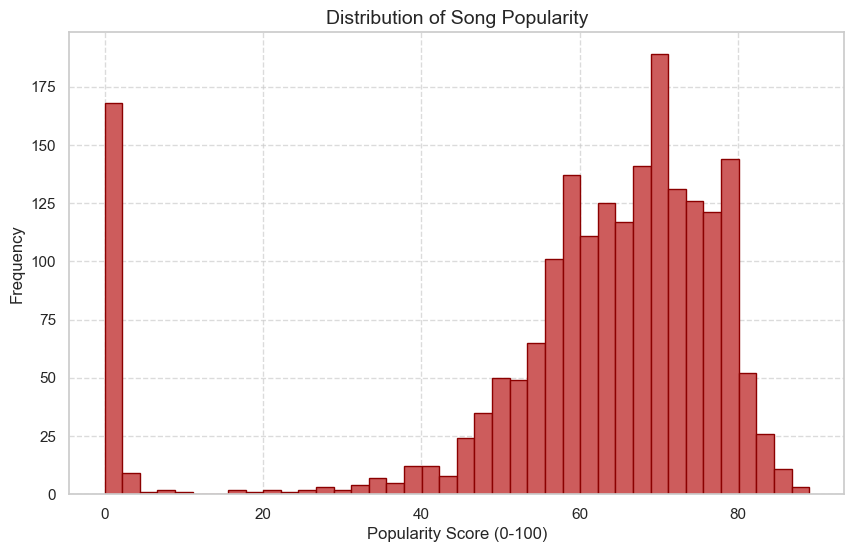

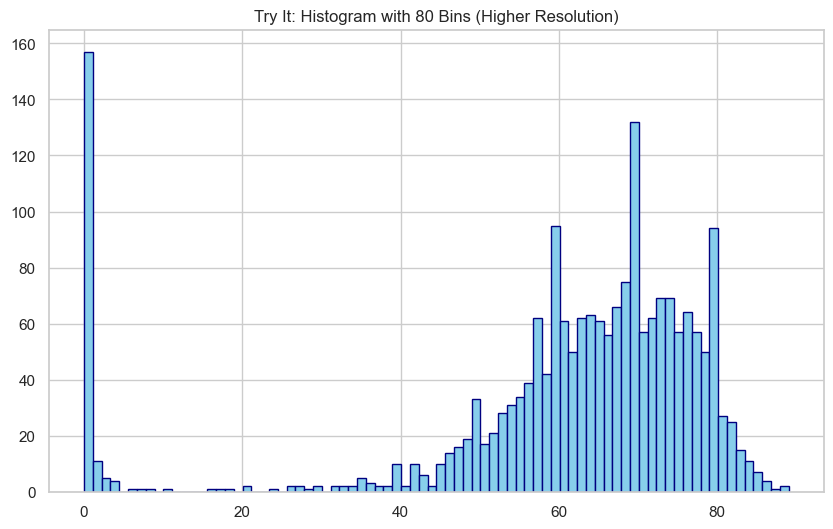

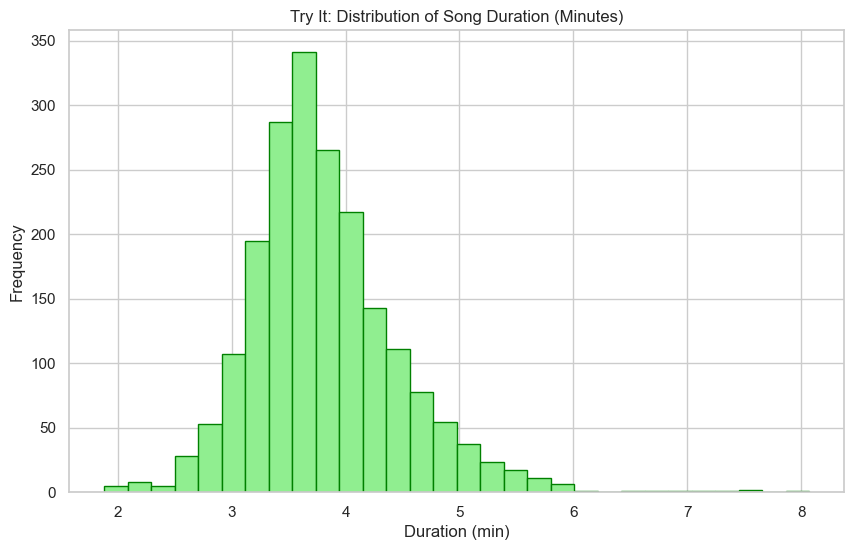

In [20]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


plt.hist(df['popularity'], bins=40, color='indianred', edgecolor='darkred')


plt.title('Distribution of Song Popularity', fontsize=14)
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Frequency')


plt.grid(True, linestyle='--', alpha=0.7)


plt.show()

# --- Try It Section ---

plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=80, color='skyblue', edgecolor='navy')
plt.title('Try It: Histogram with 80 Bins (Higher Resolution)')
plt.show()

# 1. Create the column by dividing milliseconds by 60,000
df['duration_min'] = df['duration_ms'] / 60000

# 2. Now run your histogram code
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['duration_min'], bins=30, color='lightgreen', edgecolor='green')
plt.title('Try It: Distribution of Song Duration (Minutes)')
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.show()

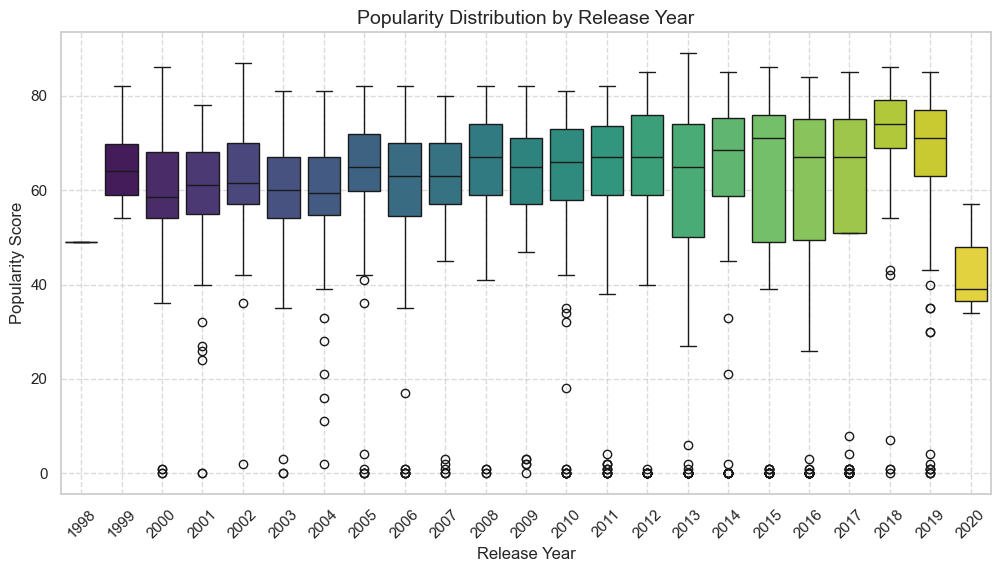

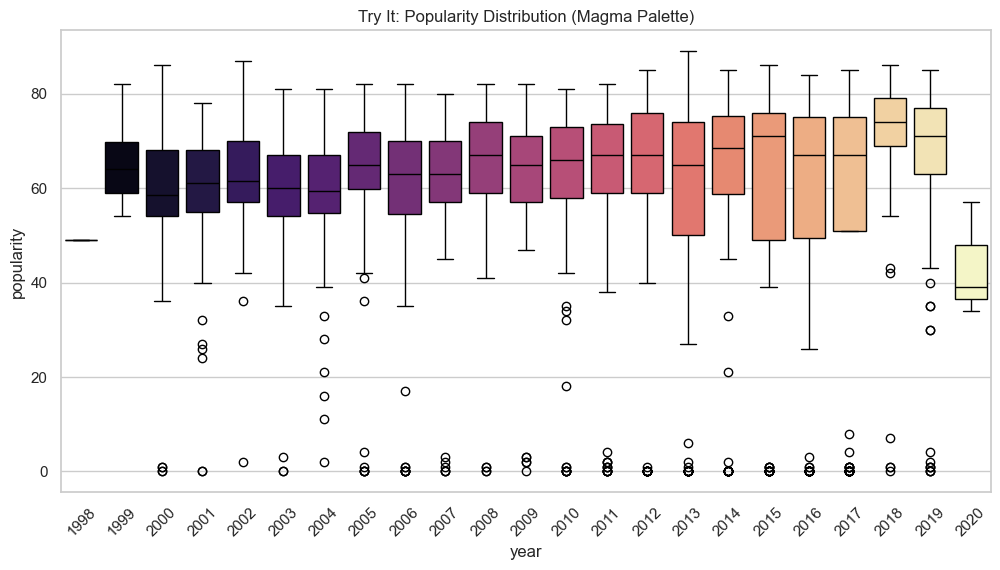

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# First Plot: Viridis
plt.figure(figsize=(12, 6))
# Adding hue='year' and legend=False satisfies the new Seaborn requirements
sns.boxplot(x='year', y='popularity', data=df, palette='viridis', hue='year', legend=False)
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Try It Section ---
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data=df, palette='magma', hue='year', legend=False)
plt.title('Try It: Popularity Distribution (Magma Palette)')
plt.xticks(rotation=45)
plt.show()

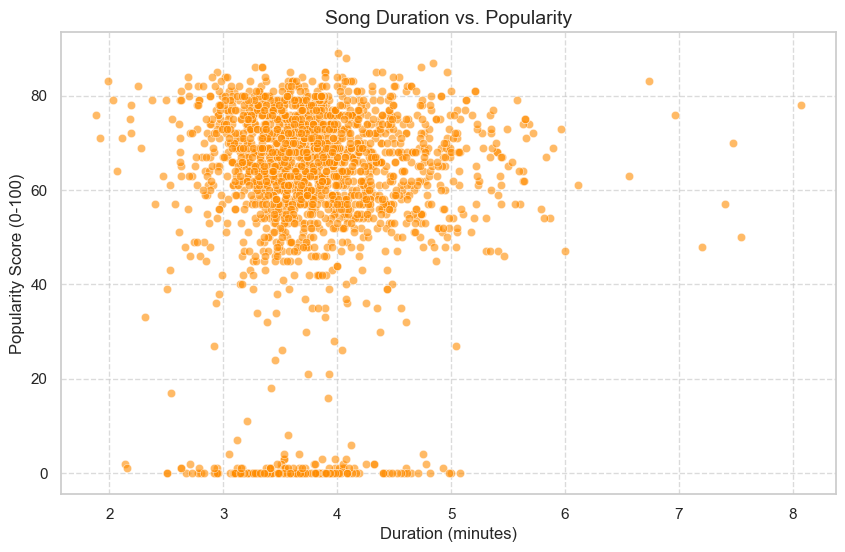

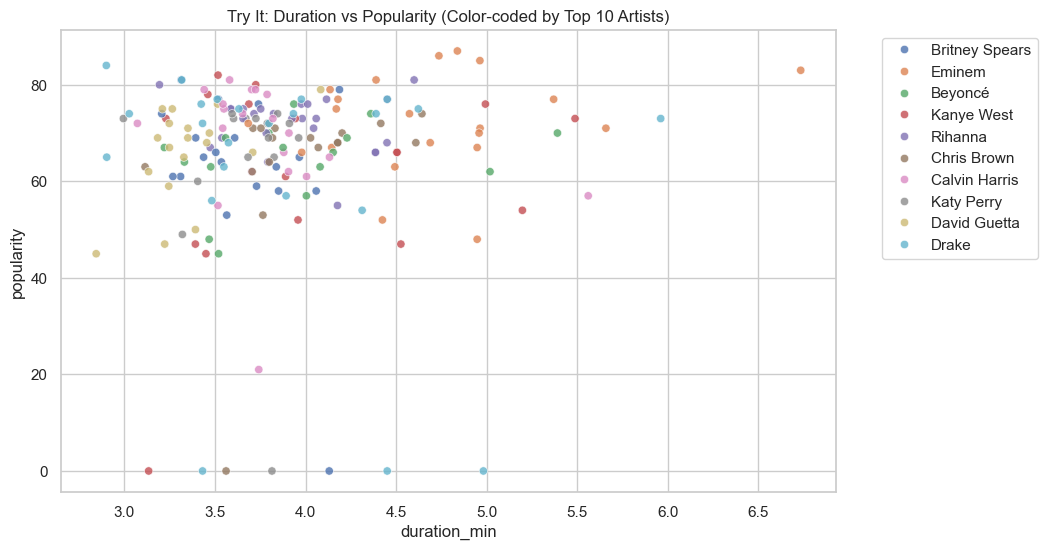

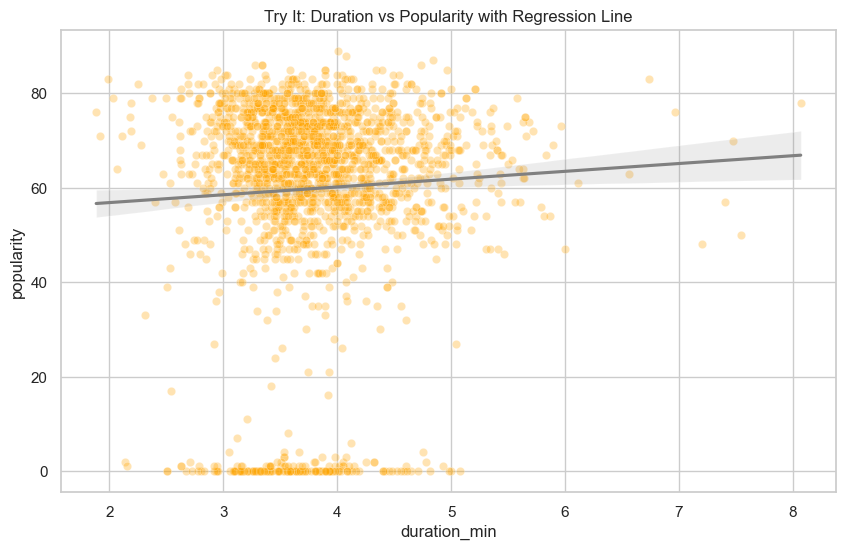

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))


sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.6, color='darkorange')


plt.title('Song Duration vs. Popularity', fontsize=14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Try It Section ---


top_10_artists = df['artist'].value_counts().nlargest(10).index
filtered_df = df[df['artist'].isin(top_10_artists)]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', hue='artist', data=filtered_df, alpha=0.8)
plt.title('Try It: Duration vs Popularity (Color-coded by Top 10 Artists)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()


plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min', y='popularity', data=df, alpha=0.3, color='orange')

sns.regplot(x='duration_min', y='popularity', data=df, scatter=False, color='grey')
plt.title('Try It: Duration vs Popularity with Regression Line')
plt.show()

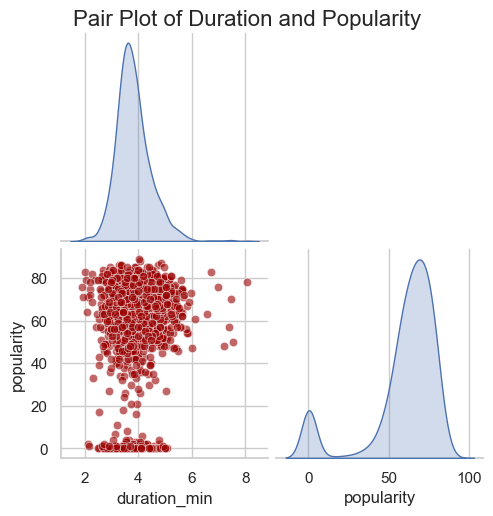


--- Running 'Try It' Variation ---


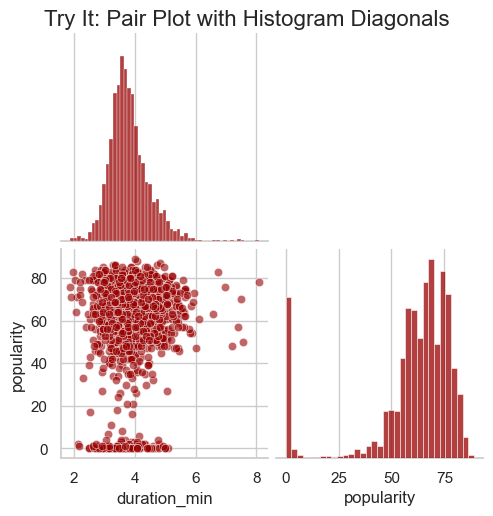

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


key_features = ['duration_min', 'popularity']


sns.pairplot(
    df[key_features], 
    diag_kind='kde', 
    corner=True,     
    plot_kws={'alpha': 0.6, 'color': '#990000'} 
)


plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize=16)


plt.show()

# --- Try It Section ---


print("\n--- Running 'Try It' Variation ---")
sns.pairplot(
    df[key_features], 
    diag_kind='hist', 
    corner=True, 
    plot_kws={'alpha': 0.6, 'color': '#990000'},
    diag_kws={'color': '#990000', 'edgecolor': 'white'}
)
plt.suptitle('Try It: Pair Plot with Histogram Diagonals', y=1.02, fontsize=16)
plt.show()

✅ File loaded from local folder!
Displaying Main Joint Plot...


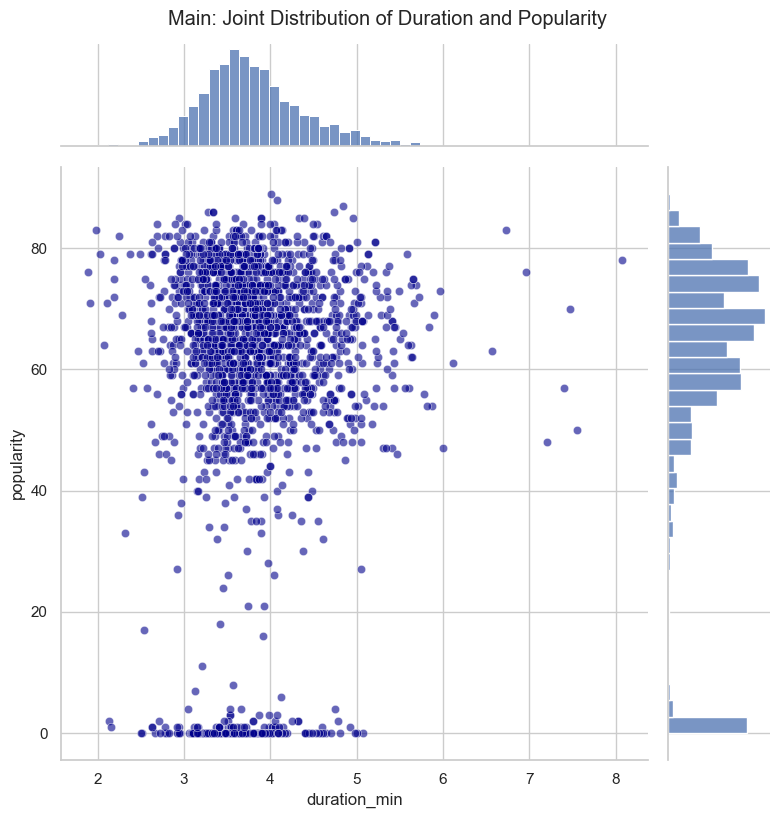


Displaying 'Try It' Variation (Regression + 25 Bins)...


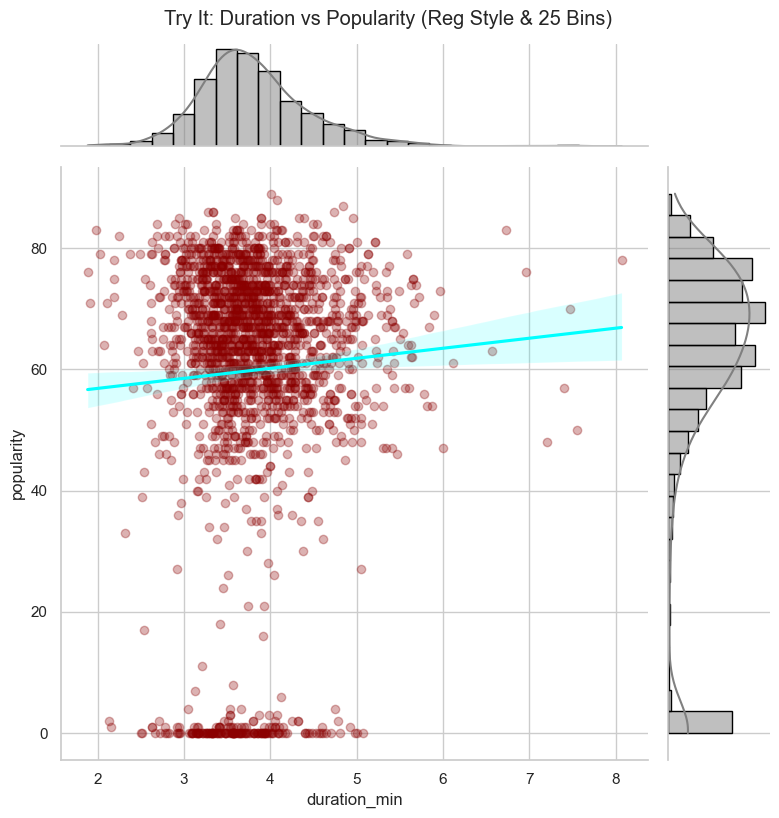

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fix 1: Use the filename that actually exists in your COMPROG folder
# We also make sure the duration_min column is created
try:
    df = pd.read_csv('songs_normalize.csv')
    df['duration_min'] = df['duration_ms'] / 60000
    print("✅ File loaded from local folder!")
except:
    print("❌ Could not find 'songs_normalize.csv'. Using the df already in memory.")

# --- MAIN PART: Standard Scatter Joint Plot ---
print("Displaying Main Joint Plot...")
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='scatter', 
    height=8,
    joint_kws={'alpha': 0.6, 'color': 'darkblue'})
plt.suptitle('Main: Joint Distribution of Duration and Popularity', y=1.02)
plt.show()

# --- TRY IT ---
print("\nDisplaying 'Try It' Variation (Regression + 25 Bins)...")
sns.jointplot(
    x='duration_min',
    y='popularity',
    data=df,
    kind='reg', 
    height=8,
    marginal_kws=dict(bins=25, color='gray', edgecolor='black'), 
    joint_kws={
        'line_kws': {'color': 'cyan'}, 
        'scatter_kws': {'alpha': 0.3, 'color': 'darkred'}
    })
plt.suptitle('Try It: Duration vs Popularity (Reg Style & 25 Bins)', y=1.02)
plt.show()

In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser

# 1. Use the local filename that worked before
csv_file = "songs_normalize.csv" 
df = pd.read_csv(csv_file)

# 2. Fix the Year logic (Your file already has a 'year' column as an integer)
# We group by the existing 'year' column
yearly_popularity = df.groupby('year')['popularity'].mean().reset_index().sort_values('year')

def animate(i, line, data):
    subset = data.iloc[:i+1]
    line.set_data(subset['year'], subset['popularity'])
    return line,

# ==========================================================
# --- PART A: MAIN TASK (Standard Speed: 100ms) ---
# ==========================================================
print("Generating Main Task GIF (100ms)...")
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax1.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line1, = ax1.plot([], [], color='royalblue', linewidth=2.5, label='Average Popularity')
ax1.set_title("Main: Track Popularity Over Time", fontsize=14)
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Popularity")
ax1.legend()

ani_main = FuncAnimation(fig1, animate, fargs=(line1, yearly_popularity), 
                         frames=len(yearly_popularity), interval=100, repeat=False)

main_gif_path = os.path.abspath("yearly_popularity_main.gif")
ani_main.save(main_gif_path, writer=PillowWriter(fps=10))
print(f"✅ Main GIF saved at: {main_gif_path}")
plt.close(fig1)

# ==========================================================
# --- PART B: TRY IT TASK (Fast Speed: 60ms) ---
# ==========================================================
print("\nGenerating Try It GIF (60ms)...")
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax2.set_ylim(0, yearly_popularity['popularity'].max() * 1.1)
line2, = ax2.plot([], [], color='crimson', linewidth=2.5, label='Average Popularity')
ax2.set_title("Try It: Track Popularity Over Time (Fast)", fontsize=14)
ax2.set_xlabel("Year")
ax2.set_ylabel("Avg Popularity")
ax2.legend()

ani_try = FuncAnimation(fig2, animate, fargs=(line2, yearly_popularity), 
                        frames=len(yearly_popularity), interval=60, repeat=False)

try_gif_path = os.path.abspath("yearly_popularity_try_it.gif")
ani_try.save(try_gif_path, writer=PillowWriter(fps=15))
print(f"✅ Try It GIF saved at: {try_gif_path}")
plt.close(fig2)

print("\nOpening both GIFs...")
webbrowser.open(f"file://{main_gif_path}")
webbrowser.open(f"file://{try_gif_path}")

Generating Main Task GIF (100ms)...
✅ Main GIF saved at: c:\Users\ADMIN\OneDrive\Documents\Desktop\COMPROG\yearly_popularity_main.gif

Generating Try It GIF (60ms)...
✅ Try It GIF saved at: c:\Users\ADMIN\OneDrive\Documents\Desktop\COMPROG\yearly_popularity_try_it.gif

Opening both GIFs...


True